# Empirical results

**4.1. Descriptive results**
- 4.1.1. Magnitude of the drift (Figure 2) (done, but SUE percentage isn't matching)
- 4.1.2. Relation of drift to firm size (Figure 3, 4) (done, data isn't looking the best)
- 4.1.3. Longevitiy of the drift (Table 1) (done, same data dynamic but not exact matches, just need some proper framing)

**4.2. Test of risk premiums as explanation for the drift**
- 4.2.1. Shifts in Betas
- 4.2.2. ATP risk factors as potential explanation
- 4.2.3. Consistent profitability of the strategy
- 4.2.4. Raw returns on bad news firms

**4.3. Tests of transactions costs as explanation for drift**
- 4.3.1. Upper bound constraint
- 4.3.2. Abnormal returns: long VS short

**4.4. Tests of whether prices fail to reflect full implication of current earnings for future earnings**

## **4.1. Descriptive results**
### **4.1.1. Magnitude of the drift**

***FIG. 2.-Cumulative abnormal returns (CARs) for SUE portfolios: all announcements.***


*Earnings announcements are assigned to deciles based on standing of standardized unexpected earnings (SUE) relative to prior-quarter SUE distribution. Based on 84,792 announcements from 1974 to 1986. CARs are the sums over pre- and postannouncement holding periods (beginning day -59 and day 1, respectively) of the difference between daily returns and returns for NYSE/AMEX firms of the same size decile. SUE represents forecast errors from a first-order autoregressive earnings expectation model (in seasonal differences) scaled by its estimation-period standard deviation (see section 3.2 for details).*

Result: a long D1 - short D10 strat would yield a 4.2% abnormal return over the 60 days subsequent period (18%). It's 17% for the continuously balanced SUE.

- We need to compute CAR (cumulated Abnormal returns). CARs are the sums over pre- and postannouncement holding periods (beginning day -59 and day 1, respectively) of the difference between daily returns and returns for NYSE/AMEX firms of the same size decile
- Earnings announcements are assigned to deciles based on standing of standardized unexpected earnings (SUE) relative to prior-quarter SUE distribution.

We begin by loading SUE filtered quartered.

In [13]:
import pandas as pd
import numpy as np

df_sue_final = pd.read_csv("../data/SUE.csv")
df_sue_final['datadate'] = pd.to_datetime(df_sue_final['datadate'])
df_sue_final['gvkey'] = df_sue_final['gvkey'].astype(str)

We then assign SUE deciles based in prior-quarter distribution to avoid any hindsight bias that would magnify the drift.

In [14]:
df_sue_final['prev_fyearq'] = np.where(df_sue_final['fqtr'] == 1, df_sue_final['fyearq'] - 1, df_sue_final['fyearq'])
df_sue_final['prev_fqtr']   = np.where(df_sue_final['fqtr'] == 1, 4, df_sue_final['fqtr'] - 1)

# Compute decile boundaries from prior-quarter distribution
decile_bounds = (
    df_sue_final.groupby(['fyearq', 'fqtr'])['SUE']
    .quantile(np.arange(0.1, 1.0, 0.1))
    .unstack()
    .reset_index()
    .rename(columns={'fyearq': 'prev_fyearq', 'fqtr': 'prev_fqtr'})
)

# Rename quantile columns to avoid float key issue
decile_bounds.columns = ['prev_fyearq', 'prev_fqtr'] + [f'd{i}' for i in range(1, 10)]

df_sue_final = df_sue_final.merge(decile_bounds, on=['prev_fyearq', 'prev_fqtr'], how='left')

# Vectorized decile assignment using boundary columns
bound_cols = [f'd{i}' for i in range(1, 10)]
bounds_arr = df_sue_final[bound_cols].values
sue_arr    = df_sue_final['SUE'].values

# For each row, count how many boundaries the SUE exceeds → decile
df_sue_final['SUE_decile'] = (sue_arr[:, None] > bounds_arr).sum(axis=1) + 1

print(df_sue_final['SUE_decile'].value_counts().sort_index())

SUE_decile
1     8659
2     8184
3     8534
4     8361
5     8536
6     8261
7     8459
8     8420
9     8320
10    8578
Name: count, dtype: int64


We now compute Cumulative Abnormal Returns (CAR) on the -60,+60 days window surrounding an earnings announcement.

In [15]:
# /!\ memory intensive for 1m
dfD = pd.read_csv("../data/dfD_final.csv")

# For each firm-quarter, get the list of trading days around rdq
dfD['DlyCalDt'] = pd.to_datetime(dfD['DlyCalDt'])
df_sue_final['rdq'] = pd.to_datetime(df_sue_final['rdq'])

# Merge dfD with df_sue_final on PERMNO to get all daily returns per firm
dfD_small = dfD[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', "DlyReturns"]].copy()
dfD_small = dfD_small.sort_values(['PERMNO', 'DlyCalDt'])
dfD_small['day_rank'] = dfD_small.groupby('PERMNO').cumcount()

rdq_ranks = df_sue_final[['gvkey', 'PERMNO', 'rdq', 'SUE_decile']].merge(
    dfD_small[['PERMNO', 'DlyCalDt', 'day_rank']],
    left_on=['PERMNO', 'rdq'],
    right_on=['PERMNO', 'DlyCalDt'],
    how='left'
).rename(columns={'day_rank': 'rdq_rank'})

events = rdq_ranks[['gvkey', 'PERMNO', 'rdq', 'rdq_rank', 'SUE_decile']].dropna(subset=['rdq_rank'])
events['rdq_rank'] = events['rdq_rank'].astype(int)

# We filter before the merge
events['rank_min'] = events['rdq_rank'] - 60
events['rank_max'] = events['rdq_rank'] + 60

# Merge then filter
car_df = events.merge(dfD_small[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', 'DlyReturns', 'day_rank']], on='PERMNO', how='left')
car_df['rel_day'] = car_df['day_rank'] - car_df['rdq_rank']
car_df = car_df[(car_df['rel_day'] >= -60) & (car_df['rel_day'] <= 60)]

car_df = car_df.sort_values(['gvkey', 'rdq', 'rel_day'])
car_df['CAR'] = car_df.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].cumsum()

# Average CAR by decile and relative day
car_avg = (
    car_df.groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

print(car_avg.head(10))
print(f"Deciles: {car_avg['SUE_decile'].unique()}")
print(f"Rel days: {car_avg['rel_day'].min()} to {car_avg['rel_day'].max()}")


   SUE_decile  rel_day       CAR
0           1      -60 -0.001263
1           1      -59 -0.002641
2           1      -58 -0.003576
3           1      -57 -0.003853
4           1      -56 -0.004102
5           1      -55 -0.004918
6           1      -54 -0.006575
7           1      -53 -0.007452
8           1      -52 -0.008512
9           1      -51 -0.010023
Deciles: [ 1  2  3  4  5  6  7  8  9 10]
Rel days: -60 to 60


We now calculate long-short strategy returns, using both SUE and cont. SUE.

In [20]:
cont_SUE = pd.read_csv("../data/cont_SUE.csv")

# CAR-based long-short (D10 - D1) — all firms
car_pivot = car_avg.pivot(index='rel_day', columns='SUE_decile', values='CAR')
car_pivot['long_short'] = car_pivot[10] - car_pivot[1]
day0 = car_pivot.loc[0, 10] - car_pivot.loc[0, 1]
car_pivot['ls_norm'] = car_pivot['long_short'] - day0
r60_all  = car_pivot.loc[60, 'ls_norm'] * 100
ann_all  = ((1 + r60_all/100) ** (252/60) - 1) * 100

# Continuously balanced SUE — all firms
cont_agg = cont_SUE.groupby('match_day')[['r_ls']].mean().reset_index()
c60_all  = cont_agg['r_ls'].mean() * 100
cann_all = ((1 + c60_all/100) ** (252/60) - 1) * 100

print(f"{'Group':<10} {'CAR 60d':>10} {'CAR Ann.':>10} {'Cont 60d':>10} {'Cont Ann.':>10}")
print(f"{'All':<10} {r60_all:>9.2f}% {ann_all:>9.2f}% {c60_all:>9.2f}% {cann_all:>9.2f}%")

Group         CAR 60d   CAR Ann.   Cont 60d  Cont Ann.
All             2.72%     11.91%      3.50%     15.53%


**Comparison with the paper**

SUE 60d: 4.2.% (2.72%) (us)

SUE Ann.: 18% (11.91%) (us)

Cont. Ann.: 17% (15.33%) (us)

We can now plot Figure 2 (FIG 2 USED TO BE GOOD? NOW ITS WEIRD? CHECK WHY)

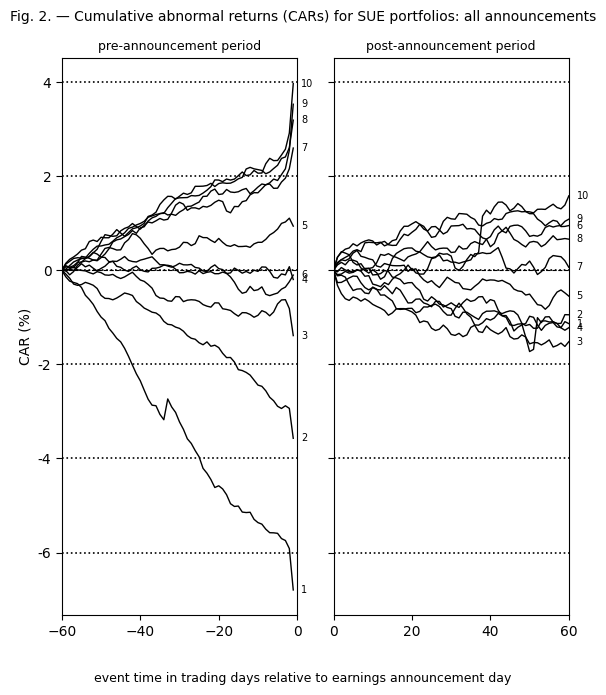

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 7), sharey=True, dpi=100)

for decile in range(1, 11):
    data = car_avg[car_avg['SUE_decile'] == decile]

    # Pre-announcement: days -60 to -1
    pre = data[(data['rel_day'] >= -60) & (data['rel_day'] < 0)].copy()
    pre['CAR_norm'] = (pre['CAR'] - pre.loc[pre['rel_day'] == -60, 'CAR'].values[0]) * 100
    ax1.plot(pre['rel_day'], pre['CAR_norm'], color='black', linewidth=1)
    last = pre[pre['rel_day'] == pre['rel_day'].max()]
    ax1.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

    # Post-announcement: days 0 to 60
    post = data[(data['rel_day'] >= 0) & (data['rel_day'] <= 60)].copy()
    post['CAR_norm'] = (post['CAR'] - post.loc[post['rel_day'] == 0, 'CAR'].values[0]) * 100
    ax2.plot(post['rel_day'], post['CAR_norm'], color='black', linewidth=1)
    last = post[post['rel_day'] == post['rel_day'].max()]
    ax2.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

ax1.set_xlim(-60, 0)
ax1.set_xticks(range(-60, 1, 20))
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 20))

for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.yaxis.set_tick_params(left=True, length=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.grid(axis='y', color='black', linestyle=':', linewidth=1.2)

ax1.set_title('pre-announcement period', fontsize=9)
ax2.set_title('post-announcement period', fontsize=9)
ax2.tick_params(labelleft=False)
ax1.set_ylabel('CAR (%)', rotation=90)

fig.text(0.5, 0.02, 'event time in trading days relative to earnings announcement day',
         ha='center', fontsize=9)
plt.suptitle('Fig. 2. — Cumulative abnormal returns (CARs) for SUE portfolios: all announcements', fontsize=10)
plt.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### **4.1.2. Relation of drift to firm size**

- Same graph, only for small firms (Figure 3)
- Same graph, only for large firms (Figure 4)
- Returns for small, medium and large firms
- Returns using continuously balanced SUE for small, medium and large firms

2 issues: we need to have the sizegroup: computing size group THEN quintiles. But if we do that, then the previous graph isn't working.

In [19]:
# Load SUE with SizeGroup
sue = pd.read_csv("../data/SUE.csv")[['gvkey', 'fyearq', 'fqtr', 'SizeGroup']]
sue['gvkey'] = sue['gvkey'].astype(str)

# Add fyearq, fqtr to car_df (needed for unique identification and SizeGroup merge)
car_df['gvkey'] = car_df['gvkey'].astype(str)
car_df_sized = car_df.merge(
    df_sue_final[['gvkey', 'rdq', 'fyearq', 'fqtr']].drop_duplicates(),
    on=['gvkey', 'rdq'],
    how='left'
).merge(sue, on=['gvkey', 'fyearq', 'fqtr'], how='left')

# Compute car_avg for small firms only
car_avg_large = (
    car_df_sized[car_df_sized['SizeGroup'] == 'large']
    .groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

# Compute car_avg for small firms only
car_avg_medium = (
    car_df_sized[car_df_sized['SizeGroup'] == 'medium']
    .groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

# Compute car_avg for small firms only
car_avg_small = (
    car_df_sized[car_df_sized['SizeGroup'] == 'small']
    .groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

KeyError: "['SizeGroup'] not in index"

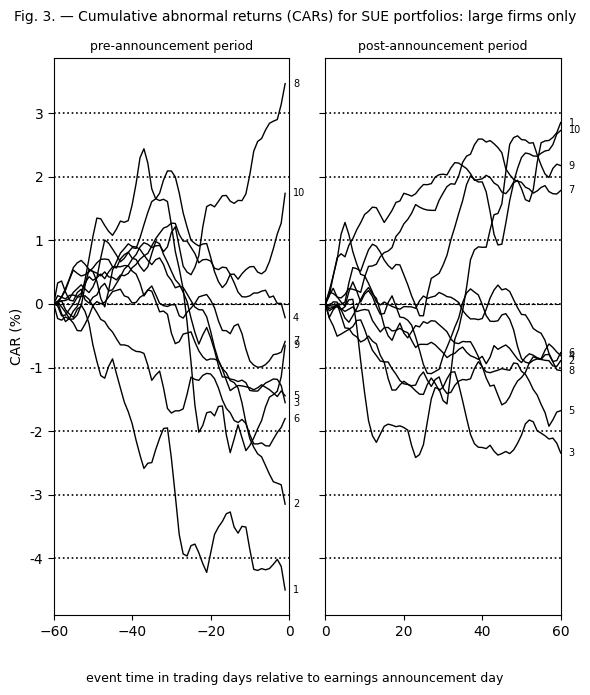

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 7), sharey=True, dpi=100)

for decile in range(1, 11):
    data = car_avg_large[car_avg_large['SUE_decile'] == decile]

    # Pre-announcement: days -60 to -1
    pre = data[(data['rel_day'] >= -60) & (data['rel_day'] < 0)].copy()
    pre['CAR_norm'] = (pre['CAR'] - pre.loc[pre['rel_day'] == -60, 'CAR'].values[0]) * 100
    ax1.plot(pre['rel_day'], pre['CAR_norm'], color='black', linewidth=1)
    last = pre[pre['rel_day'] == pre['rel_day'].max()]
    ax1.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

    # Post-announcement: days 0 to 60
    post = data[(data['rel_day'] >= 0) & (data['rel_day'] <= 60)].copy()
    post['CAR_norm'] = (post['CAR'] - post.loc[post['rel_day'] == 0, 'CAR'].values[0]) * 100
    ax2.plot(post['rel_day'], post['CAR_norm'], color='black', linewidth=1)
    last = post[post['rel_day'] == post['rel_day'].max()]
    ax2.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

ax1.set_xlim(-60, 0)
ax1.set_xticks(range(-60, 1, 20))
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 20))

for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.yaxis.set_tick_params(left=True, length=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.grid(axis='y', color='black', linestyle=':', linewidth=1.2)

ax1.set_title('pre-announcement period', fontsize=9)
ax2.set_title('post-announcement period', fontsize=9)
ax2.tick_params(labelleft=False)
ax1.set_ylabel('CAR (%)', rotation=90)

fig.text(0.5, 0.02, 'event time in trading days relative to earnings announcement day',
         ha='center', fontsize=9)
plt.suptitle('Fig. 3. — Cumulative abnormal returns (CARs) for SUE portfolios: large firms only', fontsize=10)
plt.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

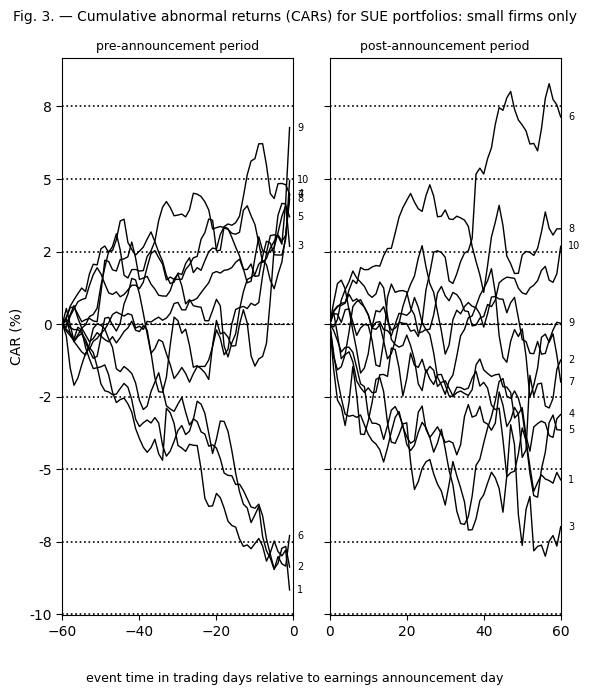

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 7), sharey=True, dpi=100)

for decile in range(1, 11):
    data = car_avg_small[car_avg_small['SUE_decile'] == decile]

    # Pre-announcement: days -60 to -1
    pre = data[(data['rel_day'] >= -60) & (data['rel_day'] < 0)].copy()
    pre['CAR_norm'] = (pre['CAR'] - pre.loc[pre['rel_day'] == -60, 'CAR'].values[0]) * 100
    ax1.plot(pre['rel_day'], pre['CAR_norm'], color='black', linewidth=1)
    last = pre[pre['rel_day'] == pre['rel_day'].max()]
    ax1.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

    # Post-announcement: days 0 to 60
    post = data[(data['rel_day'] >= 0) & (data['rel_day'] <= 60)].copy()
    post['CAR_norm'] = (post['CAR'] - post.loc[post['rel_day'] == 0, 'CAR'].values[0]) * 100
    ax2.plot(post['rel_day'], post['CAR_norm'], color='black', linewidth=1)
    last = post[post['rel_day'] == post['rel_day'].max()]
    ax2.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

ax1.set_xlim(-60, 0)
ax1.set_xticks(range(-60, 1, 20))
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 20))

for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.yaxis.set_tick_params(left=True, length=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.grid(axis='y', color='black', linestyle=':', linewidth=1.2)

ax1.set_title('pre-announcement period', fontsize=9)
ax2.set_title('post-announcement period', fontsize=9)
ax2.tick_params(labelleft=False)
ax1.set_ylabel('CAR (%)', rotation=90)

fig.text(0.5, 0.02, 'event time in trading days relative to earnings announcement day',
         ha='center', fontsize=9)
plt.suptitle('Fig. 3. — Cumulative abnormal returns (CARs) for SUE portfolios: small firms only', fontsize=10)
plt.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [9]:
print(f"{'Group':<10} {'CAR 60d':>10} {'CAR Ann.':>10} {'Cont 60d':>10} {'Cont Ann.':>10}")

for size_group, car_avg_group in [('small', car_avg_small), ('medium', car_avg_medium), ('large', car_avg_large)]:
    # CAR-based
    pivot = car_avg_group.pivot(index='rel_day', columns='SUE_decile', values='CAR')
    pivot['long_short'] = pivot[10] - pivot[1]
    day0 = pivot.loc[0, 10] - pivot.loc[0, 1]
    pivot['ls_norm'] = pivot['long_short'] - day0
    r60  = pivot.loc[60, 'ls_norm'] * 100
    ann  = ((1 + r60/100) ** (252/60) - 1) * 100

    # Continuous SUE
    cont_grp = cont_SUE[cont_SUE['size_group'] == size_group].groupby('match_day')[['r_ls']].mean().reset_index()
    c60  = cont_grp['r_ls'].mean() * 100
    cann = ((1 + c60/100) ** (252/60) - 1) * 100

    print(f"{size_group:<10} {r60:>9.2f}% {ann:>9.2f}% {c60:>9.2f}% {cann:>9.2f}%")

Group         CAR 60d   CAR Ann.   Cont 60d  Cont Ann.
small           8.05%     38.43%      6.56%     30.59%
medium          2.60%     11.38%      3.13%     13.83%
large          -0.12%     -0.52%      1.62%      6.98%


**Comparison with the paper**

SUE 60d small: 5.3% (8.1%) (us)

SUE 60d medium: 4.5% (2.6%) (us)

SUE 60d large: 2.8% (0.12%) (us)

Cont. 60d small: 5.1% (6.56%) (us)

Cont. 60d medium: 4.3% (3.13%) (us)

Cont. 60d large: 2.8% (1.62%) (us)

### **4.1.3. Longevity of the drift**

"*Table 1 provides information about the longevity of the postannouncement drift for stocks ranked in the lowest and highest SUE decile, broken down by size and by subperiods extending two years beyond the earnings announcement date.*"

This is a description of the regression table: 

They check the CAR for high and low SUE portfolios (those with SUE ranked in the highest and lowest deciles).

There are three main columns: Small Firms, Medium Firms and Large Firms. High of these are divided in 3 sub-columns: High SUE, Low SUE, Diff. (Hi-Lo).

With these columns, there are 3 large categories that each have different rows. 

Category 1: Cumulative Abnormal returns (%). Rows are Holding period (trading days, relative to announcement) There are: -59 to 0, 1 to 60, 61 to 120, 120 to 180, 181 to 240, 241 to 300, 301 to 360, 361 to 420, 421 to 480.

Category 2: Postannouncement drift (CAR, %). Rows are Holding period. There are: 1 to 60, 1 to 120, 1 to 180, 1 to 480.


Category 2: Postannouncement drift (as a fraction of 480-Day Drift). Rows are Holding period. There are: 1 to 60, 1 to 120, 1 to 180, 1 to 480.


We first need to recompute the window, from ±60 to -59,+480, keep only quarters with enough "longevity".

In [ ]:
# We filter before the merge — extend to 480 days post-announcement
events['rank_min'] = events['rdq_rank'] - 59
events['rank_max'] = events['rdq_rank'] + 480

# Merge then filter
car_df = events.merge(dfD_small[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', 'day_rank']], on='PERMNO', how='left')
car_df['rel_day'] = car_df['day_rank'] - car_df['rdq_rank']
car_df = car_df[(car_df['rel_day'] >= -59) & (car_df['rel_day'] <= 480)]

# Add SizeGroup
sue = pd.read_csv("../data/SUE.csv")[['gvkey', 'fyearq', 'fqtr', 'SizeGroup']]
sue['gvkey'] = sue['gvkey'].astype(str)
car_df['gvkey'] = car_df['gvkey'].astype(str)
car_df = car_df.merge(
    df_sue_final[['gvkey', 'rdq', 'fyearq', 'fqtr']].drop_duplicates(),
    on=['gvkey', 'rdq'], how='left'
).merge(sue, on=['gvkey', 'fyearq', 'fqtr'], how='left')

car_df = car_df.sort_values(['gvkey', 'rdq', 'rel_day'])
car_df['CAR'] = car_df.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].cumsum()

print(f"Rel days: {car_df['rel_day'].min()} to {car_df['rel_day'].max()}")
print(f"Firm-quarters with 480 days: {(car_df.groupby(['gvkey','rdq'])['rel_day'].max() >= 480).sum()}")

Rel days: -59 to 480
Firm-quarters with 480 days: 70134


We can now build the table.

In [16]:
from scipy import stats

def get_stars(tstat):
    """Convert t-statistic to significance stars"""
    pval = 2 * (1 - stats.t.cdf(abs(tstat), df=1000))  # approx with large df
    if pval < 0.01:   return '***'
    elif pval < 0.05: return '**'
    elif pval < 0.10: return '*'
    else:             return ''

def car_stats(df, start, end):
    """Returns mean CAR (%) and significance stars for H0: mean CAR = 0"""
    window = df[(df['rel_day'] >= start) & (df['rel_day'] <= end)]
    car_per_fq = window.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].sum() * 100
    car_per_fq = car_per_fq.dropna()
    if len(car_per_fq) < 2:
        return np.nan, ''
    mean  = car_per_fq.mean()
    tstat = stats.ttest_1samp(car_per_fq, 0).statistic
    return mean, get_stars(tstat)

def car_diff_stats(df_hi, df_lo, start, end):
    """Returns Diff (Hi-Lo) CAR (%) and significance stars for H0: diff = 0"""
    def get_cars(df):
        window = df[(df['rel_day'] >= start) & (df['rel_day'] <= end)]
        return window.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].sum().dropna() * 100
    car_hi = get_cars(df_hi)
    car_lo = get_cars(df_lo)
    if len(car_hi) < 2 or len(car_lo) < 2:
        return np.nan, ''
    diff  = car_hi.mean() - car_lo.mean()
    tstat = stats.ttest_ind(car_hi, car_lo).statistic
    return diff, get_stars(tstat)

intervals_cat1 = [(-59, 0), (1, 60), (61, 120), (121, 180), (181, 240), (241, 300), (301, 360), (361, 420), (421, 480)]
intervals_cat2 = [(1, 60), (1, 120), (1, 180), (1, 480)]

rows = []

for size_group in ['small', 'medium', 'large']:
    grp    = car_df[car_df['SizeGroup'] == size_group]
    grp_hi = grp[grp['SUE_decile'] == 10]
    grp_lo = grp[grp['SUE_decile'] == 1]

    # High and Low rows — only Category 1
    for label, sub in [('High', grp_hi), ('Low', grp_lo)]:
        row = {'SizeGroup': size_group, 'SUE': label}
        for s, e in intervals_cat1:
            mean, stars = car_stats(sub, s, e)
            row[f'C1 {s}:{e}'] = f'{mean:.2f}{stars}'
        rows.append(row)

    # Diff row — Category 1, 2 and 3
    row = {'SizeGroup': size_group, 'SUE': 'Diff'}

    # Category 1
    for s, e in intervals_cat1:
        diff, stars = car_diff_stats(grp_hi, grp_lo, s, e)
        row[f'C1 {s}:{e}'] = f'{diff:.2f}{stars}'
        

    # Category 2 — only Diff
    for _, e in intervals_cat2:
        diff, stars = car_diff_stats(grp_hi, grp_lo, 1, e)
        row[f'C2 1:{e}'] = f'{diff:.2f}{stars}'

    # Category 3 — only Diff, as fraction of 1-480 diff
    drift_480_hi, _ = car_stats(grp_hi, 1, 480)
    drift_480_lo, _ = car_stats(grp_lo, 1, 480)
    drift_480_diff  = drift_480_hi - drift_480_lo
    for _, e in intervals_cat2:
        diff, _ = car_diff_stats(grp_hi, grp_lo, 1, e)
        frac = diff / drift_480_diff if drift_480_diff != 0 else np.nan
        row[f'C3 1:{e}'] = f'{frac:.2f}'

    rows.append(row)

table1 = pd.DataFrame(rows)
table1 = table1.sort_values(['SizeGroup', 'SUE']).reset_index(drop=True)
print(table1.to_string())

  SizeGroup   SUE  C1 -59:0   C1 1:60 C1 61:120 C1 121:180 C1 181:240 C1 241:300 C1 301:360 C1 361:420 C1 421:480  C2 1:60 C2 1:120 C2 1:180 C2 1:480 C3 1:60 C3 1:120 C3 1:180 C3 1:480
0     large  Diff   9.92***    0.92**     0.98*    -0.91**    -1.13**   -1.26***      -0.35      -0.17       0.79   0.92**  1.89***     1.01    -1.03   -0.89    -1.83    -0.98     1.00
1     large  High   3.17***   1.46***     0.70*      -0.25      -0.52      -0.53       0.13      -0.09     0.76**      NaN      NaN      NaN      NaN     NaN      NaN      NaN      NaN
2     large   Low  -6.74***      0.54     -0.28     0.66**      0.61*    0.73***       0.48       0.08      -0.04      NaN      NaN      NaN      NaN     NaN      NaN      NaN      NaN
3    medium  Diff  11.94***   2.55***      0.73      1.00*      -0.28   -1.62***       0.06      -1.30     -0.90*  2.55***  3.28***  4.26***     0.61    4.16     5.35     6.94     1.00
4    medium  High   4.73***   1.11***      0.07      -0.07      -0.63   -1.

## **4.1. Tests of risk premiums as explanation for the drift**
### **4.2.1. Shifts in betas as a potential explanation**

Idea: "*Beta shifts are obviously a concern in a design that estimates betas in one period and then uses those estimates in a different period*."

What we check: "*Thus, while we examine the BKW hypothesis that betas shift around the time of earnings announcements, our ultimate concern is with any differences in the levels of betas for high- and low-SUE firms in the postannouncement period.*"

Beta estimate: derived using the BKW methodology for permitting betas to shift through time. For each of several 60-day windows surrounding the earnings announcement, we compounded:
- total returns on invididual stocks ($R_{jt}$)
- treasury bills ($R_{ft}$) derived on a daily basis from weekly returns calculated by Gautam Kaul for bills in their final week before maturity. Kaul's weekly returns were allocated to days assuming the same return for each day within the day.
- value-weighted CRSP index ($R_{mt}$)

These trhee data points constitute a single observation for a regression based on the Sharpe-Lintner-Mossin CAPM: $$R_{jt}=R_{fr}=a+b(R_{mt}-R_{ft})+e_{jt}$$

The regression was estimated by pooling all observations for a given SUE decile, within six 60-trading-day window surrounding the ernings announcement date. 

*Table 2 description: Beta estimates by SUE category, in periods surrounding earnings announcement. For each 60-day window, we calculate compounded daily returns for individual stocks, the value-weighted CRSP index, and the treasury-bill rate. These data constitute a single observation in a regression of individual stock returns against market returns, both expressed in terms of differences from the treasury-bill rate. Such regressions are estimated within each SUE category. There are approximately 8,500 (overlapping and thus nonindependent) observations underlying estimates for the (-59, 0) and (1, 60) windows, and slightly fewer for other windows. The standard error for each estimate in the table is approximately 0.02. Cross-sectional dependence in the data may cause downward bias in the estimated standard error (Bernard [1987]).*

**Column 1**: Preannouncement period. Subcolumns: (-119,60) and (-59, 0)

**Column 2**: Postannouncement period. Subcolumns: (1,60), (61-120), (121, 180), (181, 240)

Rows for category 1 with all these columns: Beta estimate: from 1 through 10. For category 2: Rank correlation: only 1 row (SUE and beta). For category 3: Jensen's alpha: SUE=1, SUE=10 and combined.

We only add statistical tests for category 2 & 3, with only * or nothing, with * indicating Significantly different from zero, .05 level (two-tailed test).

For the treasury bills rate and the value-weighted CRSP index, we use [Fama/French 3 Factors (Daily)](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) file. Mkt_RF is value-weighted CRSP indux minus RF, and RF is the risk-free rate.

In [21]:
ff = pd.read_csv("../data/F-F_3Factors_daily.csv", sep=';')
ff.columns = ['Date', 'Mkt_RF', 'SMB', 'HML', 'RF']
ff['Date'] = pd.to_datetime(ff['Date'].astype(str), format='%Y%m%d')
ff[['Mkt_RF', 'SMB', 'HML', 'RF']] = ff[['Mkt_RF', 'SMB', 'HML', 'RF']].astype(float) / 100

ff['Rm'] = ff['Mkt_RF'] + ff['RF']
ff = ff[['Date', 'RF', 'Rm']]

# We filter our selected period
ff = ff[(ff['Date'] >= '1974-01-01') & (ff['Date'] <= '1986-12-31')]
print(ff.head())


            Date      RF      Rm
13040 1974-01-02  0.0003  0.0029
13041 1974-01-03  0.0003  0.0235
13042 1974-01-04  0.0003 -0.0054
13043 1974-01-07  0.0003 -0.0049
13044 1974-01-08  0.0003 -0.0174
